# 03 EDA: Patient Profiles

## Purpose
Explore demographics, vital signs, lifestyle variables, insurance type, and baseline disease burden to understand the patient population before modeling.

## Imports

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"
for directory in [FIGURES_DIR, TABLES_DIR, MODELS_DIR, DATA_DIR / "processed"]:
    directory.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data_cleaning import load_raw_data, clean_all
from src.features import build_patient_features
from src.visualization import set_plot_style, save_fig, plot_multimorbidity_distribution

set_plot_style()

## Data loading

In [2]:
data = clean_all(load_raw_data(DATA_DIR))
patients = data["patients"]
patients.head()

,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,heart_rate,temperature_f,smoking_status,alcohol_use,...,dx_heart_failure,dx_atrial_fibrillation,dx_chronic_kidney_disease,dx_copd,dx_asthma,dx_depression,dx_anxiety,dx_hypothyroidism,dx_osteoarthritis,dx_type1_diabetes
0,P0000001,66.0,M,23.5,148.0,81.0,64,98.4,former,light,...,0,0,1,0,0,0,0,0,1,0
1,P0000002,75.0,M,24.8,158.0,86.0,45,99.5,never,moderate,...,0,0,0,0,1,0,0,0,1,0
2,P0000003,82.0,M,17.8,135.0,57.0,90,98.2,never,light,...,0,0,1,0,0,0,0,0,0,0
3,P0000004,73.0,F,28.1,118.0,83.0,102,98.9,former,moderate,...,0,0,0,0,0,0,0,0,0,0
4,P0000005,86.0,F,30.6,156.0,81.0,56,98.7,never,heavy,...,0,0,0,0,1,1,0,1,0,0


## Main analysis

In [3]:
patients[["age", "bmi", "systolic_bp", "diastolic_bp", "heart_rate", "charlson_index"]].describe().round(2)

,age,bmi,systolic_bp,diastolic_bp,heart_rate,charlson_index
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,71.63,27.51,133.65,84.39,72.02,0.81
std,17.29,5.40,19.25,12.47,11.89,1.03
min,19.00,16.00,80.00,50.00,45.00,0.00
25%,59.00,23.80,121.00,76.00,64.00,0.00
50%,73.00,27.50,134.00,84.00,72.00,0.00
75%,86.00,31.20,147.00,93.00,80.00,2.00
max,95.00,51.40,220.00,130.00,124.00,7.00


PosixPath('/Users/chinmaynaringrekar/PythonProject/Disease Progression and Multimorbidity Prediction/outputs/figures/03_patient_profile_distributions.png')

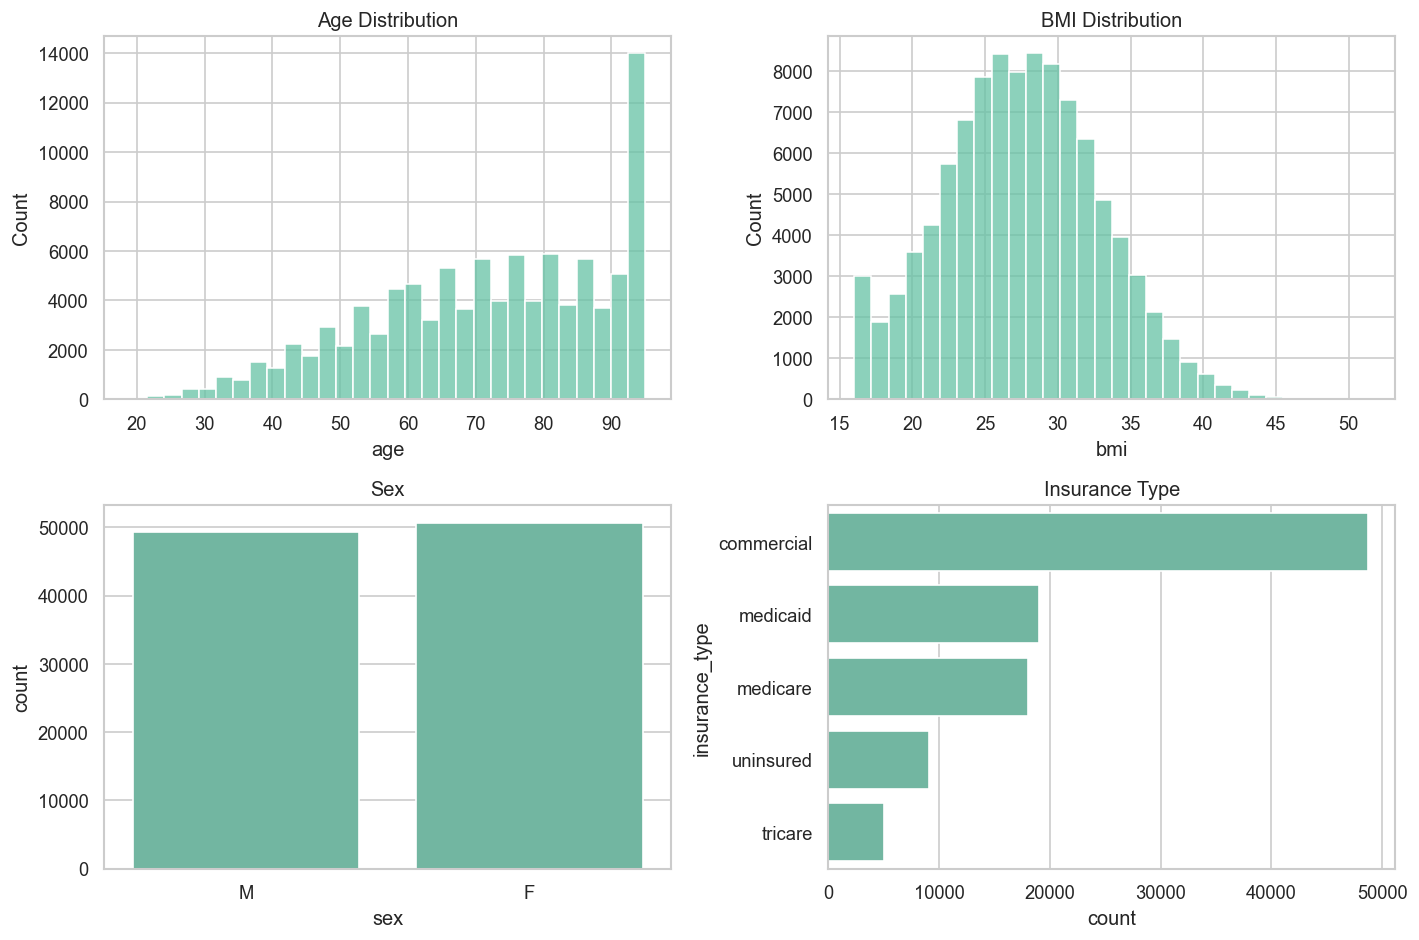

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(patients["age"], bins=30, ax=axes[0, 0])
sns.histplot(patients["bmi"], bins=30, ax=axes[0, 1])
sns.countplot(data=patients, x="sex", ax=axes[1, 0])
sns.countplot(data=patients, y="insurance_type", order=patients["insurance_type"].value_counts().index, ax=axes[1, 1])
axes[0, 0].set_title("Age Distribution")
axes[0, 1].set_title("BMI Distribution")
axes[1, 0].set_title("Sex")
axes[1, 1].set_title("Insurance Type")
fig.tight_layout()
save_fig(fig, "03_patient_profile_distributions.png")

count    100000.000000
mean          1.867070
std           1.340581
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           9.000000
Name: baseline_condition_count, dtype: float64

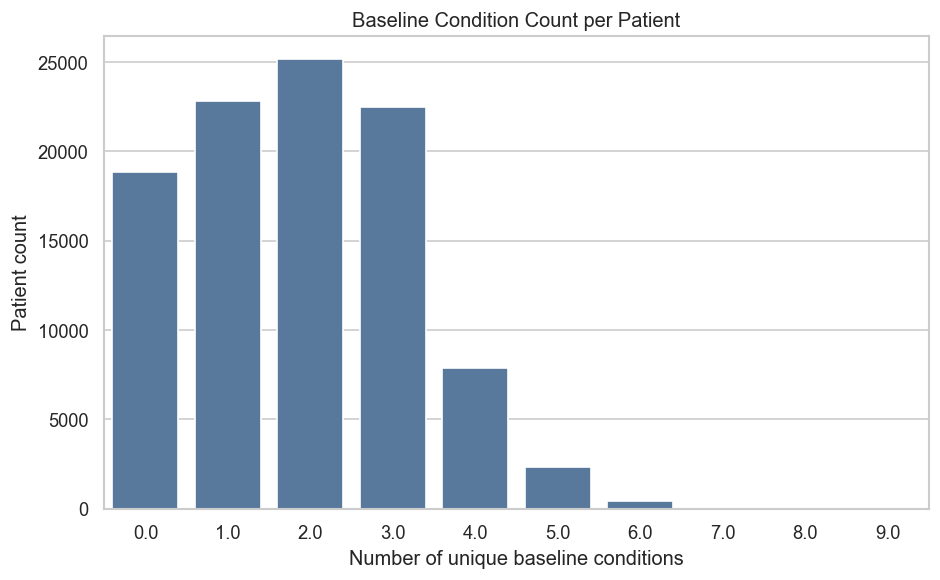

In [5]:
feature_df = build_patient_features(**data, cutoff_date="2021-12-31", horizon_end="2024-12-31")
fig, ax = plot_multimorbidity_distribution(feature_df, FIGURES_DIR / "03_baseline_condition_count.png")
feature_df["baseline_condition_count"].describe()

In [6]:
profile_by_progression = feature_df.groupby("multimorbidity_progression")[["age", "bmi", "charlson_index", "baseline_condition_count"]].mean().round(2)
profile_by_progression

,age,bmi,charlson_index,baseline_condition_count
multimorbidity_progression,,,,
0,71.10,27.52,0.84,2.21
1,74.06,27.47,0.71,0.34


## Key findings

- The patient table contains demographic, vital sign, lifestyle, insurance, and comorbidity information.
- Baseline multimorbidity burden is created from dated diagnosis events rather than all-time diagnosis flags.
- These exploratory summaries help motivate which variables should be included as predictors.

## Saved outputs

In [7]:
profile_by_progression.to_csv(TABLES_DIR / "03_profile_by_progression.csv")
print("Saved EDA figures and profile table.")

Saved EDA figures and profile table.
